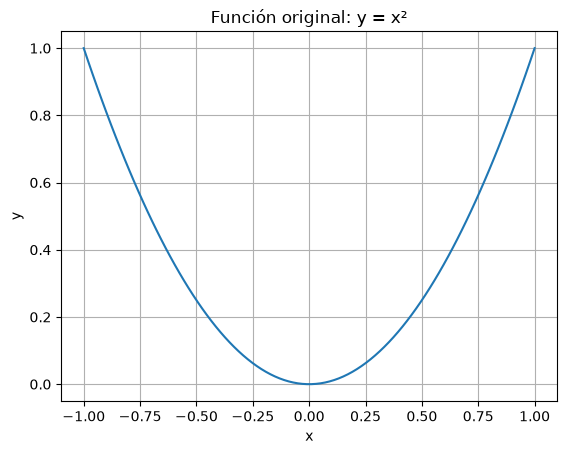

Época: 0 Error: 0.29561761113912915
Época: 500 Error: 0.0037977162963871154
Época: 1000 Error: 0.0021702139000419553
Época: 1500 Error: 0.0016410399647943266
Época: 2000 Error: 0.001291959111858604
Época: 2500 Error: 0.001047318643377432
Época: 3000 Error: 0.0008673271786981473
Época: 3500 Error: 0.0007299795811882236
Época: 4000 Error: 0.0006222753914814865
Época: 4500 Error: 0.0005360422711166834


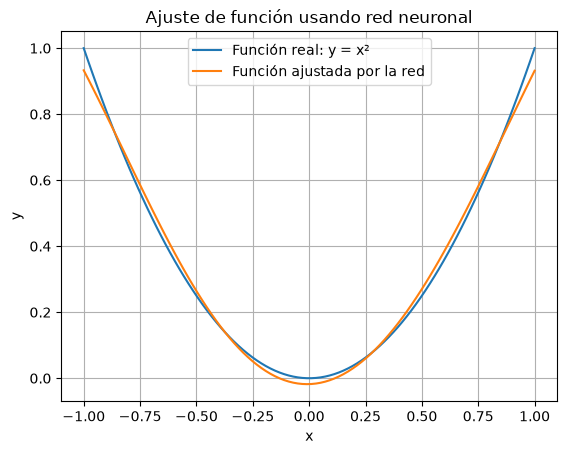

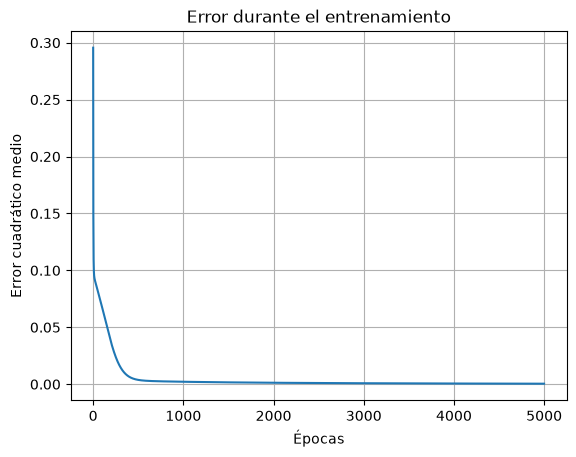

Entrada: -0.8
Predicción de la red: 0.6562298342693462
Valor real: 0.6400000000000001
-------------------------
Entrada: -0.5
Predicción de la red: 0.26426017062338863
Valor real: 0.25
-------------------------
Entrada: 0.0
Predicción de la red: -0.017842018895344536
Valor real: 0.0
-------------------------
Entrada: 0.5
Predicción de la red: 0.27024827379016486
Valor real: 0.25
-------------------------
Entrada: 0.8
Predicción de la red: 0.6508814822086415
Valor real: 0.6400000000000001
-------------------------


In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 

X = np.linspace(-1, 1, 100).reshape(-1, 1)
y = X ** 2
#Este es un comentario

plt.plot(X, y) 
plt.title("Función original: y = x²") 
plt.xlabel("x") 
plt.ylabel("y") 
plt.grid(True) 
plt.show()


def tanh(x): 
    return np.tanh(x)

def derivada_tanh(x): 
    return 1 - np.tanh(x) ** 2

np.random.seed(42)
neuronas_entrada = 1
neuronas_ocultas = 5
neuronas_salida = 1

W1 = np.random.randn(neuronas_entrada, neuronas_ocultas)
b1 = np.zeros((1, neuronas_ocultas))
W2 = np.random.randn(neuronas_ocultas, neuronas_salida)
b2 = np.zeros((1, neuronas_salida))


def propagacion_adelante(X, W1, b1, W2, b2):
    Z1 = np.dot(X, W1) + b1
    A1 = tanh(Z1)
    Z2 = np.dot(A1, W2) + b2
    return Z1, A1, Z2

def calcular_error(y_real, y_predicha):
    return np.mean((y_real - y_predicha) ** 2)

def entrenar_red(X, y, W1, b1, W2, b2, tasa_aprendizaje, epocas):
    errores = []
    n = len(X)
    for epoca in range(epocas):
        
        Z1, A1, y_predicha = propagacion_adelante(X, W1, b1, W2, b2)
        
        # Cálculo del error
        error = calcular_error(y, y_predicha)
        errores.append(error)
        
        # Retropropagación
        dZ2 = (y_predicha - y) 
        dW2 = np.dot(A1.T, dZ2) / n
        db2 = np.sum(dZ2, axis=0, keepdims=True) / n
        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * derivada_tanh(Z1)
        dW1 = np.dot(X.T, dZ1) / n
        db1 = np.sum(dZ1, axis=0, keepdims=True) / n
        
        # Actualización de parámetros
        W2 = W2 - tasa_aprendizaje * dW2
        b2 = b2 - tasa_aprendizaje * db2
        W1 = W1 - tasa_aprendizaje * dW1
        b1 = b1 - tasa_aprendizaje * db1
        
        if epoca % 500 == 0:
            print("Época:", epoca, "Error:", error)
            
    return W1, b1, W2, b2, errores

tasa_aprendizaje = 0.1
epocas = 5000

W1, b1, W2, b2, errores = entrenar_red(
    X,
    y,
    W1,
    b1,
    W2,
    b2,
    tasa_aprendizaje,
    epocas
)


Z1, A1, y_predicha = propagacion_adelante(X, W1, b1, W2, b2)


plt.plot(X, y, label="Función real: y = x²")
plt.plot(X, y_predicha, label="Función ajustada por la red")
plt.title("Ajuste de función usando red neuronal")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


plt.plot(errores)
plt.title("Error durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Error cuadrático medio")
plt.grid(True)
plt.show()


nuevos_valores = np.array([
    [-0.8],
    [-0.5],
    [0.0],
    [0.5],
    [0.8]
])

Z1_nuevo, A1_nuevo, predicciones_nuevas = propagacion_adelante(
    nuevos_valores, 
    W1,
    b1,
    W2,
    b2
)

for i in range(len(nuevos_valores)):
    print("Entrada:", nuevos_valores[i][0])
    print("Predicción de la red:", predicciones_nuevas[i][0])
    print("Valor real:", nuevos_valores[i][0] ** 2)
    print("-------------------------")